In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [3]:
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop", "gdppc", "iso3"]
]

In [19]:
# ECMWF Forecast and ERA5 baseline adjusted to GMFD
POREALLAS_ERA5_URI = "gs://poreallas-public-20260605/v20260825/parsed/era5_adj-q100.zarr"
POREALLAS_TAS_FORECAST_URI = "gs://poreallas-public-20260605/v20260825/parsed/forecast_adj-q100.zarr"

era5 = xr.load_dataset(
        POREALLAS_ERA5_URI,
        engine="zarr",
        backend_kwargs={"storage_options": {"token": "anon"}},
    ).resample(time='MS').mean()

In [20]:
era5_running = xr.open_zarr("/home/emily_zuetell/projects/poreallas/data/26_era5_running_adj_tas.zarr").resample(time='MS').mean()

In [16]:
era5_running

<xarray.Dataset> Size: 2GB
Dimensions:    (longitude: 360, time: 7167, latitude: 180)
Coordinates:
  * longitude  (longitude) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * time       (time) object 57kB 2007-01-01 00:00:00 ... 2026-08-20 00:00:00
  * latitude   (latitude) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
    number     int64 8B ...
Data variables:
    tas        (longitude, time, latitude) float32 2GB dask.array<chunksize=(45, 896, 23), meta=np.ndarray>
Attributes:
    poreallas_created_at:   2026-08-26T20:25:13.147679+00:00
    poreallas_uid:          0e4adeb8-98e5-4772-8d3d-5dc4dd6481db
    poreallas_description:  QDM bias-adjusted ERA5 (running 2026) climate fields

In [5]:
forecast = xr.load_dataset(
        POREALLAS_TAS_FORECAST_URI,
        engine="zarr",
        backend_kwargs={"storage_options": {"token": "anon"}},
    ).resample(time='MS').mean()

In [7]:
forecast

<xarray.Dataset> Size: 106MB
Dimensions:    (time: 8, latitude: 180, longitude: 360, number: 51)
Coordinates:
  * time       (time) object 64B 2026-08-01 00:00:00 ... 2027-03-01 00:00:00
  * latitude   (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * number     (number) int64 408B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
Data variables:
    tas        (time, latitude, longitude, number) float32 106MB 265.6 ... 246.4
Attributes:
    poreallas_created_at:   2026-08-26T04:08:04.804007+00:00
    poreallas_uid:          078e9723-816c-49bb-9154-507e78a82ec3
    poreallas_description:  QDM bias-adjusted forecast ensemble fields

In [ ]:
# Convert Ensemble Average to Impact Regions
anomaly_era5_running_ir = isku_utils.grid_to_ir(era5_running['tas'], savefile="gmfd_era5_running_ir")
#anomaly_era5_ir = isku_utils.grid_to_ir(era5['tas'], savefile="gmfd_era5_ir")
anomaly_forecast_ir = isku_utils.grid_to_ir(forecast['tas'], savefile="gmfd_forecast_ir")


/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is

FileExistsError: Cannot create '' with mode 'w-' because it already contains data. Use mode 'w' to overwrite or 'a' to append.

In [22]:
merged_era5 = xr.merge([anomaly_era5_ir.rename('anomaly'), socioeconomics])
merged_era5_running = xr.merge([anomaly_era5_running_ir.rename('anomaly'), socioeconomics])
merged_forecast = xr.merge([anomaly_forecast_ir.rename('anomaly'), socioeconomics])

In [23]:
pop_weighted_anomaly_era5 = (merged_era5['anomaly'] * merged_era5['pop']).sum(dim='region') / merged_era5['pop'].sum(dim='region')
pop_weighted_anomaly_era5_running = (merged_era5_running['anomaly'] * merged_era5_running['pop']).sum(dim='region') / merged_era5_running['pop'].sum(dim='region')
pop_weighted_anomaly_forecast = (merged_forecast['anomaly'] * merged_forecast['pop']).sum(dim='region') / merged_forecast['pop'].sum(dim='region')

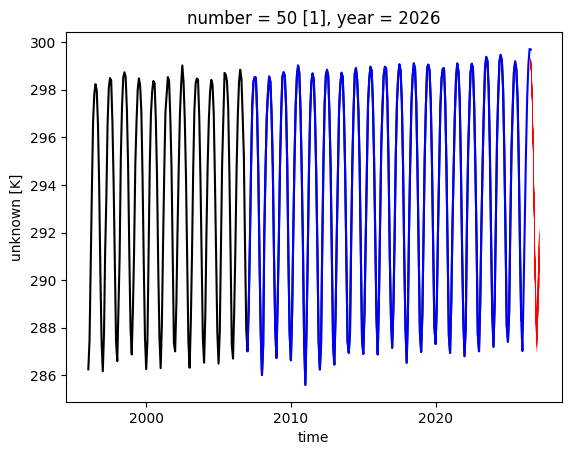

In [29]:
pop_weighted_anomaly_era5.plot(color = 'k')
pop_weighted_anomaly_era5_running.plot(color = 'b')
for i in range(1, 51):
    pop_weighted_anomaly_forecast.sel(number=i).plot(color = 'r', linewidth=0.2)

In [30]:
era5

<xarray.Dataset> Size: 93MB
Dimensions:    (time: 360, longitude: 360, latitude: 180)
Coordinates:
  * time       (time) object 3kB 1996-01-01 00:00:00 ... 2025-12-01 00:00:00
  * longitude  (longitude) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * latitude   (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
Data variables:
    tas        (time, longitude, latitude) float32 93MB 231.1 230.9 ... 270.4
Attributes:
    poreallas_created_at:   2026-08-26T04:04:07.904087+00:00
    poreallas_uid:          72d6df01-91f1-4525-a088-8bbb8ca98c64
    poreallas_description:  QDM bias-adjusted ERA5 climate fields

In [ ]:
# Monthly climatology
era5_climatology = era5.sel(time = slice()).groupby('time.month').mean(dim='time')